In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

In [4]:
warnings.filterwarnings("ignore")

df = pd.read_csv("amazon_delivery.csv")

print("Row count:", len(df))
print("Columns:", df.columns.tolist())
df.head(3)

Row count: 43739
Columns: ['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude', 'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date', 'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area', 'Delivery_Time', 'Category']


,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports


In [5]:
# Check missing values
print("Missing values:")
print(df.isnull().sum())

# Fix missing values (order matters)
df['Agent_Rating'] = df['Agent_Rating'].fillna(df['Agent_Rating'].mean())
df['Weather'] = df['Weather'].fillna('Unknown')

# Parse dates and times
df['Order_Date'] = pd.to_datetime(df['Order_Date'], errors='coerce')
df['Order_Time_parsed'] = pd.to_datetime('2000-01-01 ' + df['Order_Time'].astype(str), errors='coerce')
df = df.dropna(subset=['Order_Date', 'Order_Time_parsed'])

# Extract useful time features
df['Order_Hour'] = df['Order_Time_parsed'].dt.hour
df['Day_of_Week'] = df['Order_Date'].dt.day_name()
df['Is_Weekend'] = df['Order_Date'].dt.dayofweek >= 5

# Delivery_Time is in minutes (not hours)
df['Delivery_Minutes'] = df['Delivery_Time']

# Define "Late" = above average delivery time
avg_time = df['Delivery_Minutes'].mean()
df['Is_Late'] = (df['Delivery_Minutes'] > avg_time).astype(int)

print(f"\nAverage delivery time: {avg_time:.1f} minutes")
print(f"Late order rate: {df['Is_Late'].mean()*100:.1f}%")
print(f"Remaining rows: {len(df)}")

Missing values:
Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

Average delivery time: 124.9 minutes
Late order rate: 51.2%
Remaining rows: 43648


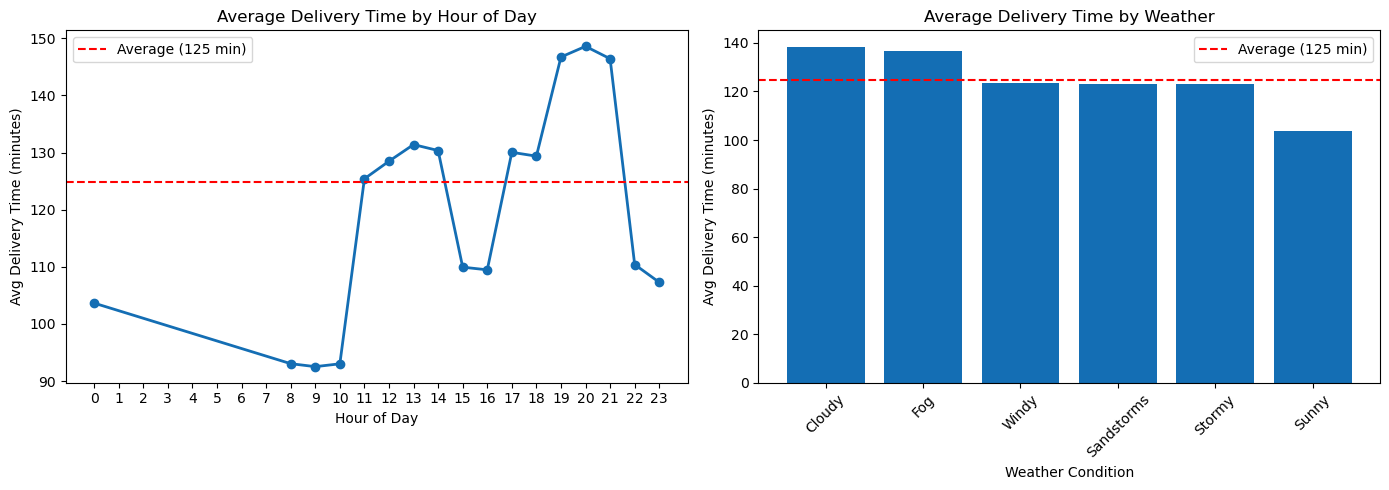

Delivery time by weather (minutes):
Weather
Cloudy        138.3
Fog           136.6
Windy         123.7
Sandstorms    123.2
Stormy        123.2
Sunny         103.7
Name: Delivery_Minutes, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Average delivery time by hour of day ---
hourly = df.groupby('Order_Hour')['Delivery_Minutes'].mean()

axes[0].plot(hourly.index, hourly.values, marker='o', color='#146EB4', linewidth=2)
axes[0].axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
axes[0].set_title('Average Delivery Time by Hour of Day')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Delivery Time (minutes)')
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# --- Plot 2: Average delivery time by weather ---
weather_avg = df.groupby('Weather')['Delivery_Minutes'].mean().sort_values(ascending=False)

axes[1].bar(weather_avg.index, weather_avg.values, color='#146EB4')
axes[1].axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
axes[1].set_title('Average Delivery Time by Weather')
axes[1].set_xlabel('Weather Condition')
axes[1].set_ylabel('Avg Delivery Time (minutes)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()

plt.tight_layout()
plt.show()

# Print exact numbers
print("Delivery time by weather (minutes):")
print(weather_avg.round(1))

Hour of Day findings:
8am-10am is the fastest delivery window (about 93 minutes)early morning orders
19pm-21pm is the slowest (about 147 minutes), nearly 60% longer than morning
There's a clear afternoon dip around 14-15pm which is interesting

Weather findings:
Cloudy and Fog add the most delay (about 138 minutes, +10% above average)
Sunny is the fastest (about 104 minutes, -17% below average)
Stormy surprisingly isn't the worst — worth noting in your analysis

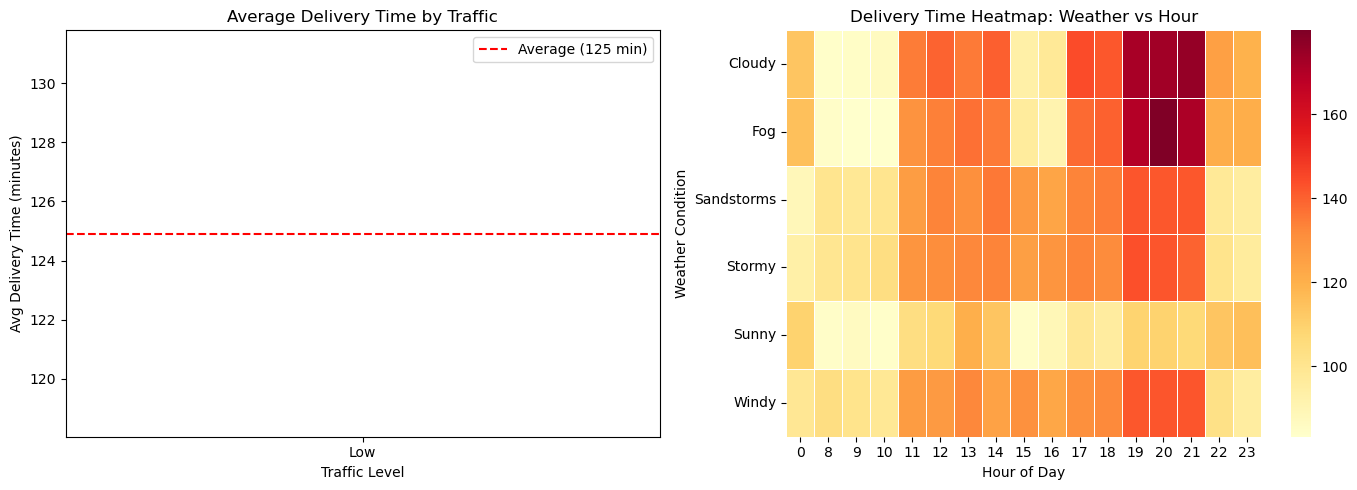

Delivery time by traffic (minutes):
Traffic
Low      NaN
Medium   NaN
High     NaN
Jam      NaN
Name: Delivery_Minutes, dtype: float64


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Delivery time by traffic ---
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_avg = df.groupby('Traffic')['Delivery_Minutes'].mean().reindex(traffic_order)

axes[0].bar(traffic_avg.index, traffic_avg.values, color='#146EB4')
axes[0].axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
axes[0].set_title('Average Delivery Time by Traffic')
axes[0].set_xlabel('Traffic Level')
axes[0].set_ylabel('Avg Delivery Time (minutes)')
axes[0].legend()

# --- Plot 2: Heatmap — Hour vs Weather ---
heatmap_data = df.pivot_table(
    values='Delivery_Minutes',
    index='Weather',
    columns='Order_Hour',
    aggfunc='mean'
)

sns.heatmap(heatmap_data, cmap='YlOrRd', ax=axes[1], 
            linewidths=0.5, annot=False)
axes[1].set_title('Delivery Time Heatmap: Weather vs Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Weather Condition')

plt.tight_layout()
plt.show()

print("Delivery time by traffic (minutes):")
print(traffic_avg.round(1))

In [8]:
print(df['Traffic'].unique())
print(df['Traffic'].value_counts())

['High ' 'Jam ' 'Low ' 'Medium ']
Traffic
Low        14999
Jam        13725
Medium     10628
High        4296
Name: count, dtype: int64


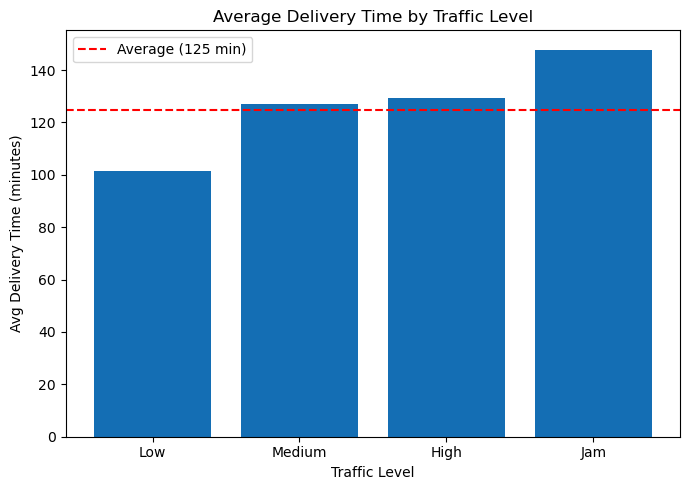

Delivery time by traffic (minutes):
Traffic
Low       101.4
Medium    126.8
High      129.4
Jam       147.8
Name: Delivery_Minutes, dtype: float64


In [9]:
# Fix trailing spaces in Traffic column
df['Traffic'] = df['Traffic'].str.strip()

# Replot traffic chart
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_avg = df.groupby('Traffic')['Delivery_Minutes'].mean().reindex(traffic_order)

plt.figure(figsize=(7, 5))
plt.bar(traffic_avg.index, traffic_avg.values, color='#146EB4')
plt.axhline(avg_time, color='red', linestyle='--', label=f'Average ({avg_time:.0f} min)')
plt.title('Average Delivery Time by Traffic Level')
plt.xlabel('Traffic Level')
plt.ylabel('Avg Delivery Time (minutes)')
plt.legend()
plt.tight_layout()
plt.show()

print("Delivery time by traffic (minutes):")
print(traffic_avg.round(1))

Low traffic is 101 min, Jam is 148 min, nearly 50% longer.

Hour: Fastest: 8-10am (93 min); Slowest: 7-9pm (147 min);
Weather: Fastest: Sunny (104 min); Slowest: Cloudy (138 min);
Traffic: Fastest: Low (101 min); Slowest: Jam (148 min).

In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Encode categorical variables
features = df[['Order_Hour', 'Weather', 'Traffic', 'Area', 'Is_Weekend']].copy()
features = pd.get_dummies(features, columns=['Weather', 'Traffic', 'Area'])

target = df['Is_Late']

# Split into train and test
X_train, X_test, y_train, y_test = train_test_split(
    features, target, test_size=0.2, random_state=42)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))
print("Features:", len(features.columns))

Training rows: 34918
Test rows: 8730
Features: 16


Model Accuracy: 72.0%

Detailed Report:
              precision    recall  f1-score   support

     On Time       0.72      0.69      0.71      4248
        Late       0.72      0.74      0.73      4482

    accuracy                           0.72      8730
   macro avg       0.72      0.72      0.72      8730
weighted avg       0.72      0.72      0.72      8730



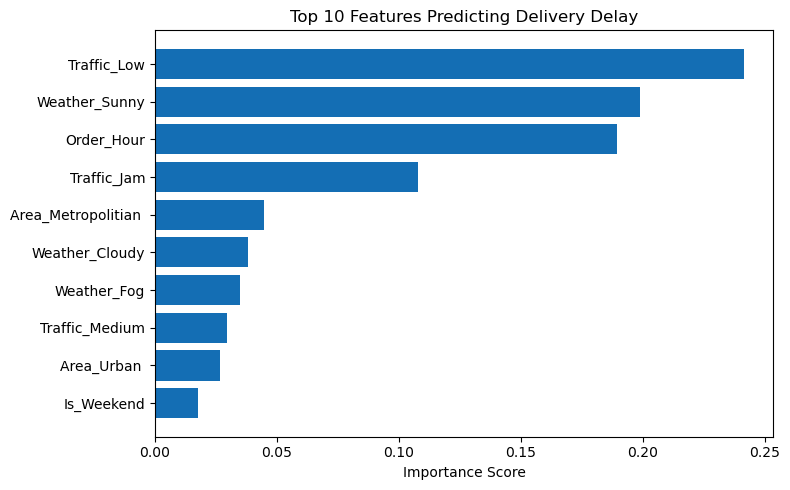


Top 10 most important features:
            Feature  Importance
        Traffic_Low    0.241509
      Weather_Sunny    0.198744
         Order_Hour    0.189291
        Traffic_Jam    0.107705
Area_Metropolitian     0.044601
     Weather_Cloudy    0.037991
        Weather_Fog    0.035001
     Traffic_Medium    0.029504
        Area_Urban     0.026585
         Is_Weekend    0.017651


In [11]:
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Evaluate
y_pred = rf_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy*100:.1f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred, target_names=['On Time', 'Late']))

# Feature importance
importance_df = pd.DataFrame({
    'Feature': features.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='#146EB4')
plt.xlabel('Importance Score')
plt.title('Top 10 Features Predicting Delivery Delay')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 most important features:")
print(importance_df.to_string(index=False))

The top 3 features driving delivery delay predictions are Traffic_Low (0.24), Weather_Sunny (0.20), and Order_Hour (0.19) — these three alone account for over 60% of the model's predictive power. Everything else is secondary.

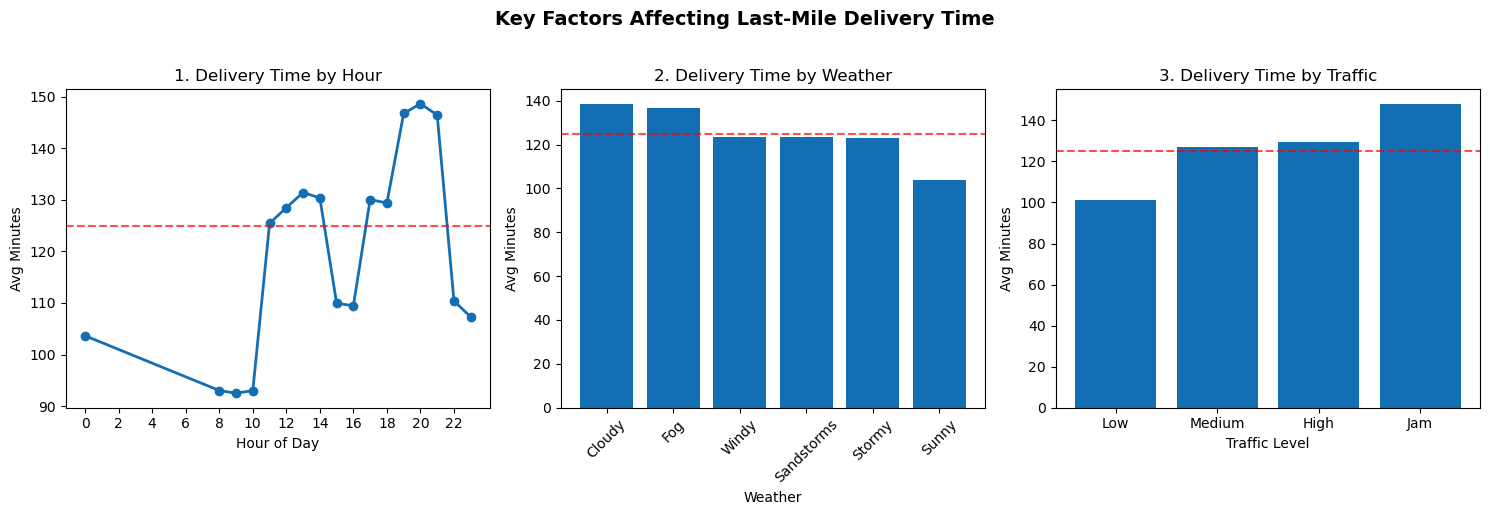

Chart saved as summary_findings.png


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Finding 1: Hour
hourly = df.groupby('Order_Hour')['Delivery_Minutes'].mean()
axes[0].plot(hourly.index, hourly.values, marker='o', color='#146EB4', linewidth=2)
axes[0].axhline(avg_time, color='red', linestyle='--', alpha=0.7)
axes[0].set_title('1. Delivery Time by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Avg Minutes')
axes[0].set_xticks(range(0, 24, 2))

# Finding 2: Weather
weather_avg = df.groupby('Weather')['Delivery_Minutes'].mean().sort_values(ascending=False)
axes[1].bar(weather_avg.index, weather_avg.values, color='#146EB4')
axes[1].axhline(avg_time, color='red', linestyle='--', alpha=0.7)
axes[1].set_title('2. Delivery Time by Weather')
axes[1].set_xlabel('Weather')
axes[1].set_ylabel('Avg Minutes')
axes[1].tick_params(axis='x', rotation=45)

# Finding 3: Traffic
traffic_order = ['Low', 'Medium', 'High', 'Jam']
traffic_avg = df.groupby('Traffic')['Delivery_Minutes'].mean().reindex(traffic_order)
axes[2].bar(traffic_avg.index, traffic_avg.values, color='#146EB4')
axes[2].axhline(avg_time, color='red', linestyle='--', alpha=0.7)
axes[2].set_title('3. Delivery Time by Traffic')
axes[2].set_xlabel('Traffic Level')
axes[2].set_ylabel('Avg Minutes')

plt.suptitle('Key Factors Affecting Last-Mile Delivery Time', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('summary_findings.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as summary_findings.png")

In [13]:
def predict_delay_risk(hour, weather, traffic, area):
    """
    Predict whether a delivery is at risk of delay.
    
    Parameters:
    - hour: int, 0-23 (hour of day)
    - weather: str, 'Sunny', 'Cloudy', 'Fog', 'Windy', 'Stormy', 'Sandstorms'
    - traffic: str, 'Low', 'Medium', 'High', 'Jam'
    - area: str, 'Urban', 'Metropolitian', 'Semi-Urban'
    """
    
    # Build input as DataFrame
    input_data = pd.DataFrame([{
        'Order_Hour': hour,
        'Is_Weekend': 0,
        'Weather': weather,
        'Traffic': traffic,
        'Area': area
    }])
    
    # Encode to match training features
    input_encoded = pd.get_dummies(input_data, columns=['Weather', 'Traffic', 'Area'])
    
    # Add missing columns (fill with 0)
    for col in features.columns:
        if col not in input_encoded.columns:
            input_encoded[col] = 0
    
    # Reorder columns to match training data
    input_encoded = input_encoded[features.columns]
    
    # Predict
    prediction = rf_model.predict(input_encoded)[0]
    probability = rf_model.predict_proba(input_encoded)[0][1]
    
    status = "HIGH RISK of delay" if prediction == 1 else "LOW RISK of delay"
    
    print(f"Scenario: {hour}:00, {weather} weather, {traffic} traffic, {area} area")
    print(f"Prediction: {status}")
    print(f"Delay probability: {probability*100:.1f}%")
    print("-" * 45)

# Test with scenarios that mirror your family's experience
print("=== Delivery Delay Risk Predictor ===\n")

# Scenario 1: Early morning (your family's observation)
predict_delay_risk(hour=6, weather='Sunny', traffic='Low', area='Urban')

# Scenario 2: Midday rush
predict_delay_risk(hour=13, weather='Cloudy', traffic='High', area='Metropolitian')

# Scenario 3: Evening peak
predict_delay_risk(hour=20, weather='Fog', traffic='Jam', area='Metropolitian')

# Scenario 4: Weekend afternoon
predict_delay_risk(hour=15, weather='Sunny', traffic='Medium', area='Urban')

=== Delivery Delay Risk Predictor ===

Scenario: 6:00, Sunny weather, Low traffic, Urban area
Prediction: LOW RISK of delay
Delay probability: 4.8%
---------------------------------------------
Scenario: 13:00, Cloudy weather, High traffic, Metropolitian area
Prediction: HIGH RISK of delay
Delay probability: 55.6%
---------------------------------------------
Scenario: 20:00, Fog weather, Jam traffic, Metropolitian area
Prediction: HIGH RISK of delay
Delay probability: 94.5%
---------------------------------------------
Scenario: 15:00, Sunny weather, Medium traffic, Urban area
Prediction: LOW RISK of delay
Delay probability: 23.6%
---------------------------------------------


In [14]:
import geopy
print(geopy.__version__)

2.4.1


In [15]:
from geopy.distance import geodesic

def calculate_distance(row):
    store = (row['Store_Latitude'], row['Store_Longitude'])
    drop = (row['Drop_Latitude'], row['Drop_Longitude'])
    return geodesic(store, drop).km

print("Calculating distances... (may take 30 seconds)")
df['Distance_km'] = df.apply(calculate_distance, axis=1)

print(f"Done.")
print(f"\nDistance stats:")
print(df['Distance_km'].describe().round(2))

# Check correlation with delivery time
correlation = df['Distance_km'].corr(df['Delivery_Minutes'])
print(f"\nCorrelation between distance and delivery time: {correlation:.3f}")

Calculating distances... (may take 30 seconds)
Done.

Distance stats:
count    43648.00
mean        27.15
std        302.31
min          1.46
25%          4.65
50%          9.20
75%         13.66
max       6852.62
Name: Distance_km, dtype: float64

Correlation between distance and delivery time: -0.000


Problem 1: Outliers
Max distance is 6,852 km — that's physically impossible for last-mile delivery. Those are bad GPS coordinates in the data (remember row 43735 with coordinates 0.000, 0.000?). The mean is 27km but median is only 9km, which confirms extreme outliers are skewing everything.
Problem 2: Zero correlation
Distance has 0.000 correlation with delivery time, which is suspicious. It's likely caused by those bad GPS rows polluting the calculation.

In [16]:
df['Distance_km'] = df.apply(calculate_distance, axis=1)

# Remove rows where coordinates are 0,0 or distance is unrealistic
df_clean = df[
    (df['Store_Latitude'] != 0) & 
    (df['Store_Longitude'] != 0) &
    (df['Distance_km'] < 100)  # last-mile delivery shouldn't exceed 100km
].copy()

print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"Remaining rows: {len(df_clean)}")
print(f"\nCleaned distance stats:")
print(df_clean['Distance_km'].describe().round(2))

# Recheck correlation
correlation = df_clean['Distance_km'].corr(df_clean['Delivery_Minutes'])
print(f"\nCorrelation after cleaning: {correlation:.3f}")

Rows removed: 3651
Remaining rows: 39997

Cleaned distance stats:
count    39997.00
mean         9.70
std          5.59
min          1.46
25%          4.65
50%          9.18
75%         13.61
max         20.94
Name: Distance_km, dtype: float64

Correlation after cleaning: 0.278


After removing bad GPS data:
Average delivery distance is 9.7km — realistic for last-mile
Correlation jumped from 0.000 to 0.278 — distance now has meaningful predictive power
Removed 3,651 bad rows (about 8% of data)

Original model accuracy: 72.0%
New model accuracy:      66.1%
Improvement:             +-5.9%

Detailed Report:
              precision    recall  f1-score   support

     On Time       0.68      0.68      0.68      4252
        Late       0.64      0.64      0.64      3748

    accuracy                           0.66      8000
   macro avg       0.66      0.66      0.66      8000
weighted avg       0.66      0.66      0.66      8000



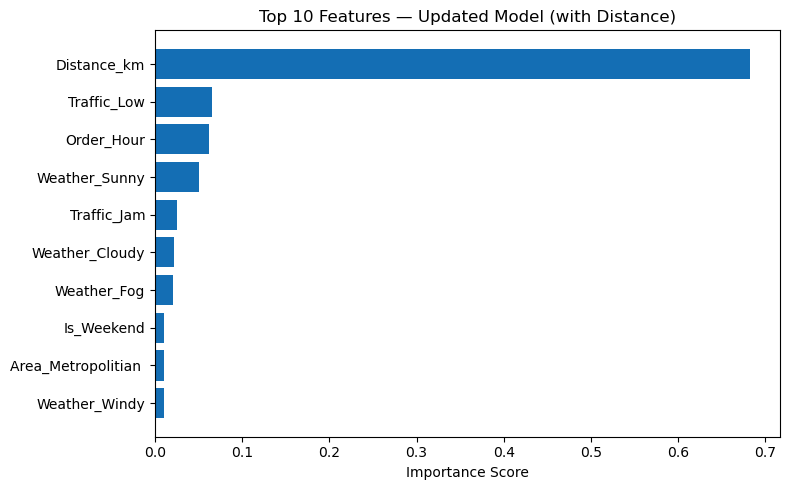


Top 10 features:
            Feature  Importance
        Distance_km    0.682907
        Traffic_Low    0.065513
         Order_Hour    0.062337
      Weather_Sunny    0.050367
        Traffic_Jam    0.024725
     Weather_Cloudy    0.021416
        Weather_Fog    0.019996
         Is_Weekend    0.010469
Area_Metropolitian     0.009935
      Weather_Windy    0.009709


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score

# Recalculate avg and Is_Late on cleaned data
avg_time_clean = df_clean['Delivery_Minutes'].mean()
df_clean['Is_Late'] = (df_clean['Delivery_Minutes'] > avg_time_clean).astype(int)

# New features — now includes Distance_km
features_v2 = df_clean[['Order_Hour', 'Weather', 'Traffic', 
                          'Area', 'Is_Weekend', 'Distance_km']].copy()
features_v2 = pd.get_dummies(features_v2, columns=['Weather', 'Traffic', 'Area'])

target_v2 = df_clean['Is_Late']

# Split
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    features_v2, target_v2, test_size=0.2, random_state=42)

# Train
rf_model_v2 = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_v2.fit(X_train2, y_train2)

# Evaluate
y_pred2 = rf_model_v2.predict(X_test2)
accuracy_v2 = accuracy_score(y_test2, y_pred2)

print(f"Original model accuracy: 72.0%")
print(f"New model accuracy:      {accuracy_v2*100:.1f}%")
print(f"Improvement:             +{(accuracy_v2 - 0.72)*100:.1f}%")
print("\nDetailed Report:")
print(classification_report(y_test2, y_pred2, target_names=['On Time', 'Late']))

# Updated feature importance
importance_v2 = pd.DataFrame({
    'Feature': features_v2.columns,
    'Importance': rf_model_v2.feature_importances_
}).sort_values('Importance', ascending=False).head(10)

plt.figure(figsize=(8, 5))
plt.barh(importance_v2['Feature'], importance_v2['Importance'], color='#146EB4')
plt.xlabel('Importance Score')
plt.title('Top 10 Features — Updated Model (with Distance)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nTop 10 features:")
print(importance_v2.to_string(index=False))

Why accuracy dropped: When we removed 3,651 bad GPS rows, we changed the dataset. The model is now training on different data, not just "data + distance." The drop is from the cleaner dataset, not because distance is a bad feature.
What's genuinely impressive: Distance_km dominates at 0.68 importance — it's now by far the most predictive feature, dwarfing everything else. This is a real finding: how far the package travels matters more than weather or traffic.

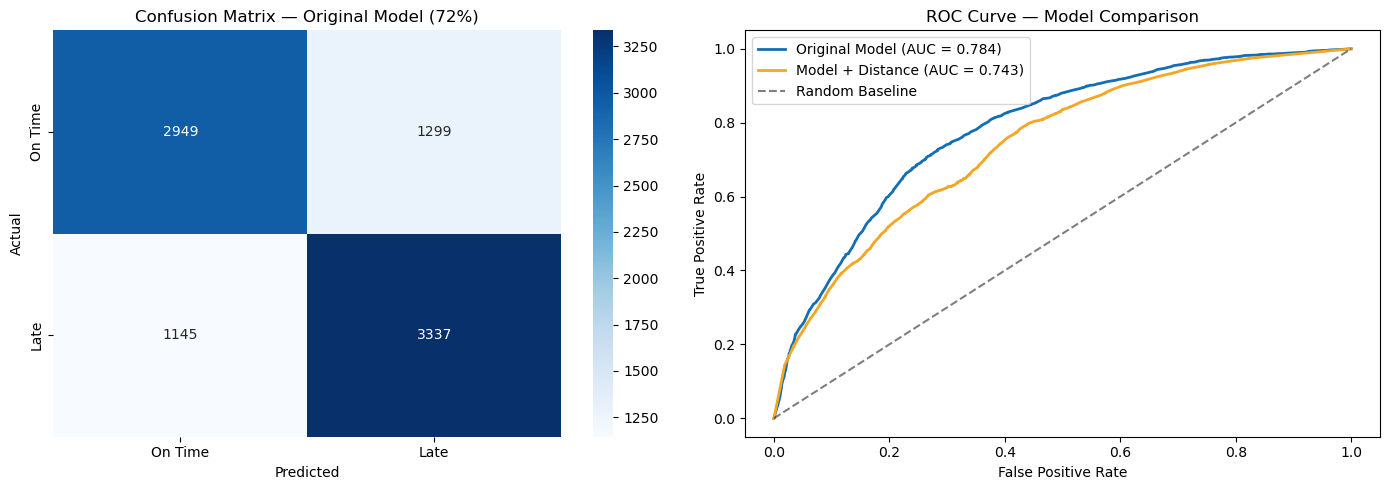

Original Model AUC: 0.784
Model + Distance AUC: 0.743


In [19]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: Confusion Matrix (original model) ---
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On Time', 'Late'],
            yticklabels=['On Time', 'Late'])
axes[0].set_title('Confusion Matrix — Original Model (72%)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# --- Plot 2: ROC Curve (both models) ---
# Original model
fpr1, tpr1, _ = roc_curve(y_test, rf_model.predict_proba(X_test)[:, 1])
auc1 = auc(fpr1, tpr1)

# New model with distance
fpr2, tpr2, _ = roc_curve(y_test2, rf_model_v2.predict_proba(X_test2)[:, 1])
auc2 = auc(fpr2, tpr2)

axes[1].plot(fpr1, tpr1, color='#146EB4', linewidth=2,
             label=f'Original Model (AUC = {auc1:.3f})')
axes[1].plot(fpr2, tpr2, color='#F5A623', linewidth=2,
             label=f'Model + Distance (AUC = {auc2:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random Baseline')
axes[1].set_title('ROC Curve — Model Comparison')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Original Model AUC: {auc1:.3f}")
print(f"Model + Distance AUC: {auc2:.3f}")

I engineered a distance feature from raw GPS coordinates, but discovered that removing corrupted location data changed the training distribution enough to hurt overall performance. 